In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings, os
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("✅ Ready")

✅ Ready


In [2]:
DATA_PATH = "../ml-service/data/crime_data.csv"

df = pd.read_csv(DATA_PATH)

if "year" not in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date"].dt.year

print(f"✅ Loaded {len(df):,} records  |  Years: {sorted(df['year'].dropna().unique().astype(int).tolist())}")
print(f"📋 Columns: {list(df.columns)}")
df.head()

✅ Loaded 9,800 records  |  Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
📋 Columns: ['incident_id', 'district', 'police_division', 'crime_type', 'date', 'day_of_week', 'is_holiday', 'time_bracket', 'location_type', 'lighting_level', 'victim_gender', 'victim_age_bracket', 'prior_offenses', 'offender_drug_history', 'reported_2015_total', 'solved_2015_total', 'cleared_rate_pct', 'reported_status', 'referral_source', 'year']


,incident_id,district,police_division,crime_type,date,day_of_week,is_holiday,time_bracket,location_type,lighting_level,victim_gender,victim_age_bracket,prior_offenses,offender_drug_history,reported_2015_total,solved_2015_total,cleared_rate_pct,reported_status,referral_source,year
0,2015-COL-001,Colombo,Colombo South,Homicide,2015-01-08,Thursday,Yes,Night,Public Space,Poorly-lit,Male,35-45,0,No,568,540,95,Solved,Police,2015
1,2015-COL-002,Colombo,Nugegoda,House Breaking,2015-04-14,Tuesday,Yes,Night,Residential,Dark,Female,45-60,1,No,9245,3050,33,Under Investigation,Police,2015
2,2015-GAM-001,Gampaha,Kelaniya,Drug Offences (Heroin),2015-02-15,Sunday,No,Morning,Transport Hub,Well-lit,Male,18-24,3,Yes,26145,25000,95,Solved,Police,2015
3,2015-KAN-001,Kandy,Kandy Central,Robbery,2015-08-10,Monday,No,Evening,Commercial,Well-lit,Male,25-35,2,No,3542,2300,65,Solved,Self-Reported,2015
4,2015-KAL-001,Kalutara,Panadura,Grievous Hurt,2015-03-22,Sunday,No,Evening,Public Space,Poorly-lit,Male,25-35,1,No,1410,1290,91,Solved,Hospital,2015


In [3]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(f"✅ Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"✅ Total records: {len(df):,}")

✅ Date range: 2015-01-08 → 2024-12-30
✅ Total records: 9,800


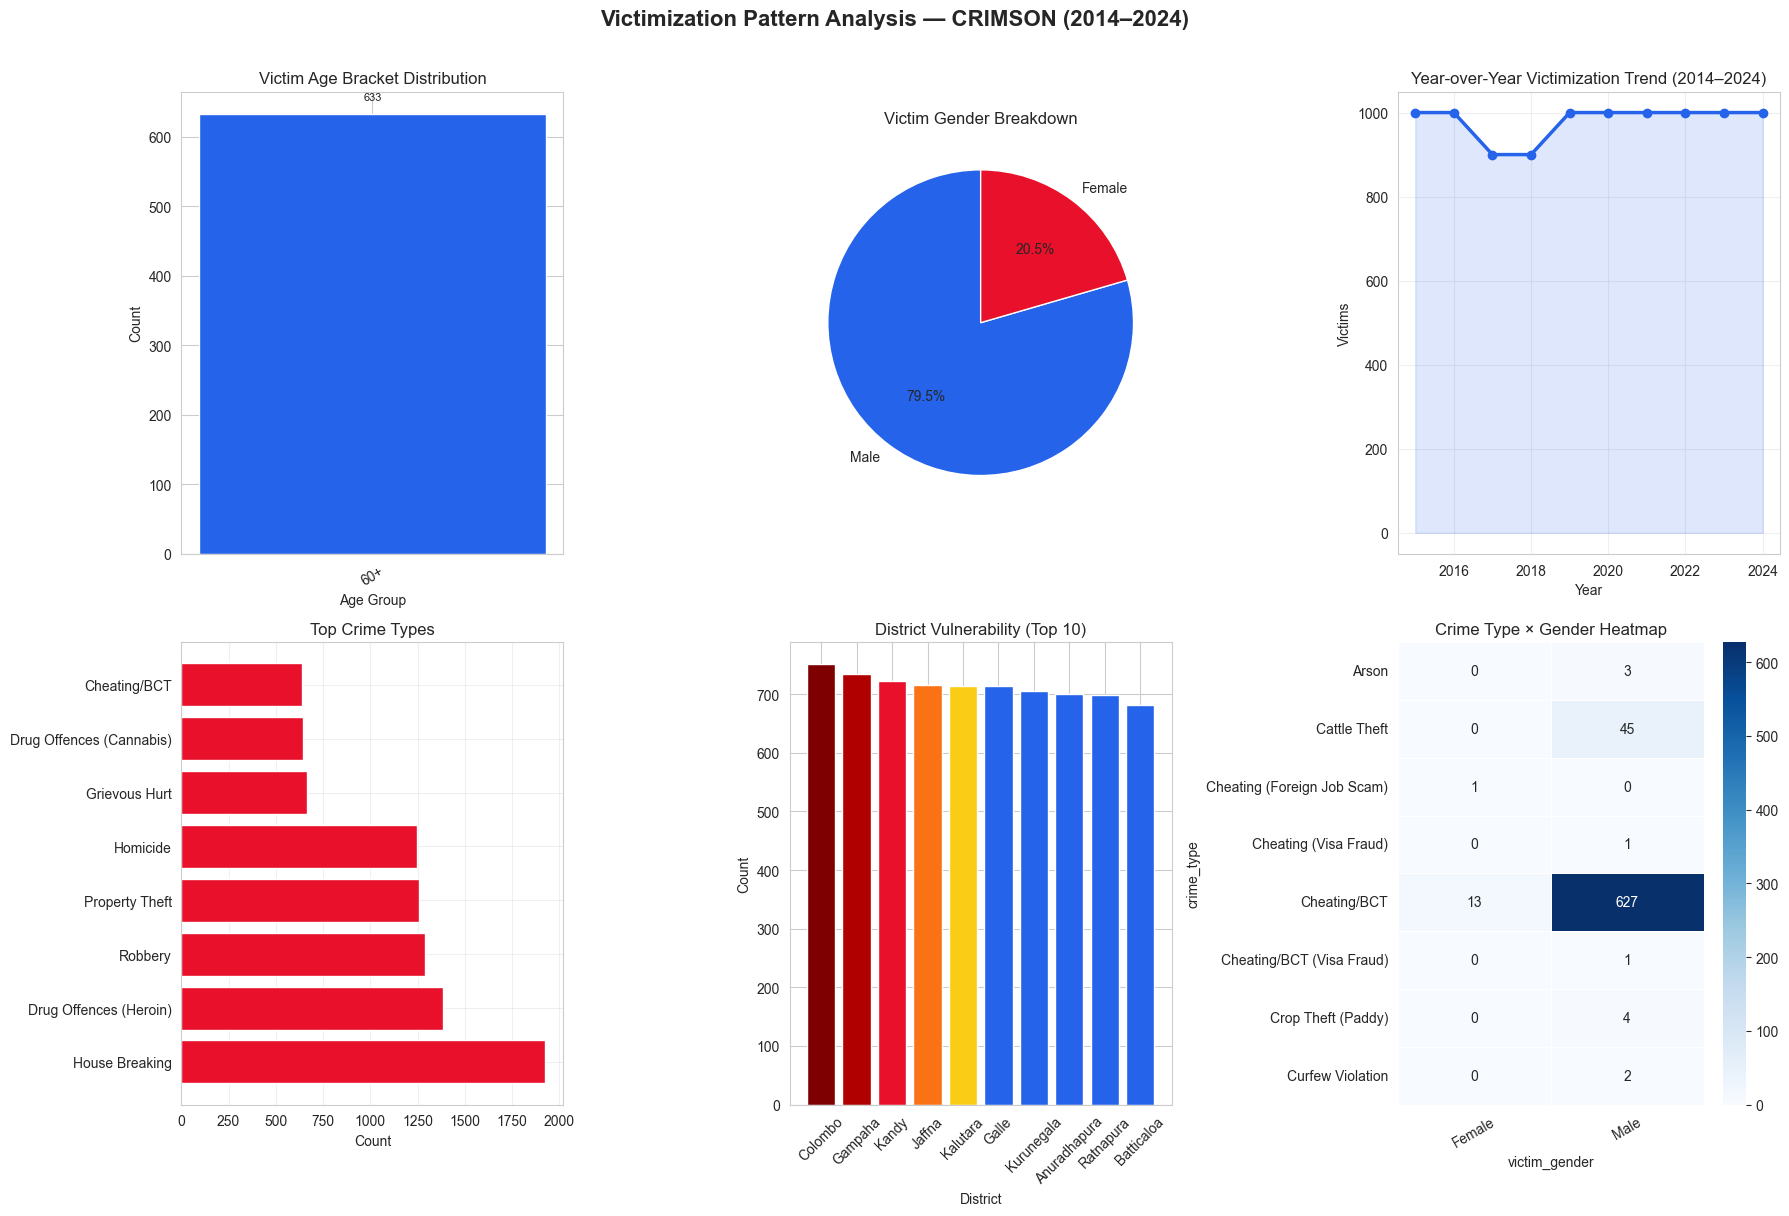

✅ Core analysis saved


In [4]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Victimization Pattern Analysis — CRIMSON (2014–2024)",
             fontsize=16, fontweight="bold", y=1.01)

ax1 = fig.add_subplot(2, 3, 1)
age_counts = df["victim_age_bracket"].value_counts()
age_order  = ["0-17","18-25","26-35","36-45","46-60","60+"]
age_counts = age_counts.reindex([a for a in age_order if a in age_counts.index])
ax1.bar(age_counts.index, age_counts.values, color="#2563eb", edgecolor="white")
ax1.set_title("Victim Age Bracket Distribution")
ax1.set_xlabel("Age Group"); ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=30)
for i, v in enumerate(age_counts.values):
    ax1.text(i, v + 20, f"{v:,}", ha="center", fontsize=8)

ax2 = fig.add_subplot(2, 3, 2)
gender_counts = df["victim_gender"].value_counts()
ax2.pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%",
        colors=["#2563eb","#e8102a","#f97316"], startangle=90)
ax2.set_title("Victim Gender Breakdown")

ax3 = fig.add_subplot(2, 3, 3)
year_trend = df.groupby("year").size()
ax3.plot(year_trend.index, year_trend.values,
         color="#2563eb", linewidth=2.5, marker="o", markersize=6)
ax3.fill_between(year_trend.index, year_trend.values, alpha=0.15, color="#2563eb")
ax3.set_title("Year-over-Year Victimization Trend (2014–2024)")
ax3.set_xlabel("Year"); ax3.set_ylabel("Victims"); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(2, 3, 4)
crime_counts = df["crime_type"].value_counts().head(8)
ax4.barh(crime_counts.index, crime_counts.values, color="#e8102a")
ax4.set_title("Top Crime Types"); ax4.set_xlabel("Count"); ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(2, 3, 5)
dist_counts = df["district"].value_counts().head(10)
colors_bar  = ["#7f0000","#b00000","#e8102a","#f97316","#facc15"] + ["#2563eb"]*5
ax5.bar(dist_counts.index, dist_counts.values,
        color=colors_bar[:len(dist_counts)], edgecolor="white")
ax5.set_title("District Vulnerability (Top 10)")
ax5.set_xlabel("District"); ax5.set_ylabel("Count")
ax5.tick_params(axis="x", rotation=45)

ax6 = fig.add_subplot(2, 3, 6)
pivot_hm = df.groupby(["crime_type","victim_gender"]).size().unstack(fill_value=0).head(8)
sns.heatmap(pivot_hm, ax=ax6, cmap="Blues", annot=True, fmt="d", linewidths=0.5)
ax6.set_title("Crime Type × Gender Heatmap")
ax6.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("victimization_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Core analysis saved")

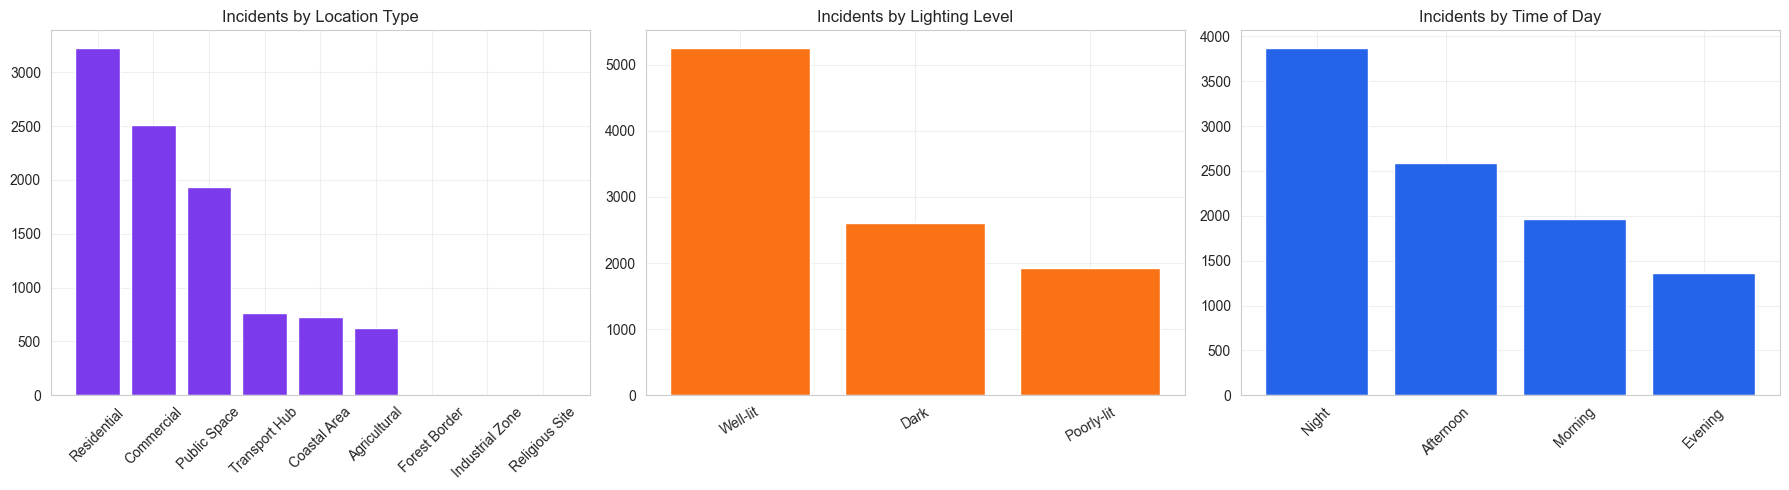

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if "location_type" in df.columns:
    loc = df["location_type"].value_counts()
    axes[0].bar(loc.index, loc.values, color="#7c3aed", edgecolor="white")
    axes[0].set_title("Incidents by Location Type")
    axes[0].tick_params(axis="x", rotation=45); axes[0].grid(True, alpha=0.3)

if "lighting_level" in df.columns:
    light = df["lighting_level"].value_counts()
    axes[1].bar(light.index, light.values, color="#f97316", edgecolor="white")
    axes[1].set_title("Incidents by Lighting Level")
    axes[1].tick_params(axis="x", rotation=30); axes[1].grid(True, alpha=0.3)

if "time_bracket" in df.columns:
    time = df["time_bracket"].value_counts()
    axes[2].bar(time.index, time.values, color="#2563eb", edgecolor="white")
    axes[2].set_title("Incidents by Time of Day")
    axes[2].tick_params(axis="x", rotation=45); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("victimization_environment.png", dpi=150)
plt.show()

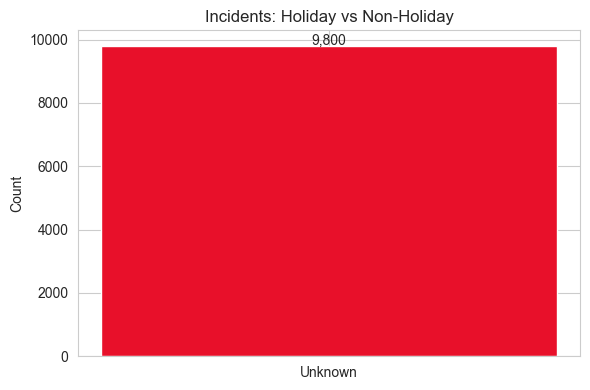

In [6]:
if "is_holiday" in df.columns:
    holiday_map = {1:"Holiday", 0:"Non-Holiday", True:"Holiday", False:"Non-Holiday"}
    df["holiday_label"] = df["is_holiday"].map(holiday_map).fillna("Unknown")

    hc = df["holiday_label"].value_counts()
    plt.figure(figsize=(6, 4))
    plt.bar(hc.index, hc.values, color=["#e8102a","#2563eb"], edgecolor="white")
    plt.title("Incidents: Holiday vs Non-Holiday")
    plt.ylabel("Count")
    for i, v in enumerate(hc.values):
        plt.text(i, v + 30, f"{v:,}", ha="center")
    plt.tight_layout()
    plt.savefig("holiday_analysis.png", dpi=150)
    plt.show()

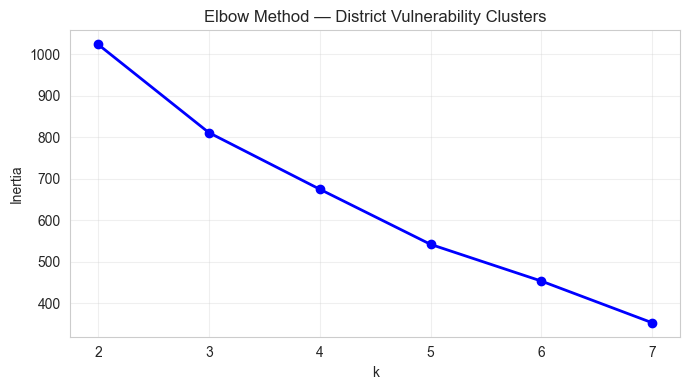


District Vulnerability Levels:
crime_type   vulnerability
district                  
Colombo               HIGH
Ampara                 LOW
Polonnaruwa            LOW
Nuwara Eliya           LOW
Mullaitivu             LOW
Monaragala             LOW
Kegalle                LOW
Vavuniya               LOW
Hambantota             LOW
Jaffna              MEDIUM
Kalutara            MEDIUM
Trincomalee         MEDIUM
Gampaha             MEDIUM
Kurunegala          MEDIUM
Matara              MEDIUM
Galle               MEDIUM
Batticaloa          MEDIUM
Badulla             MEDIUM
Anuradhapura        MEDIUM
Puttalam            MEDIUM
Ratnapura           MEDIUM
Kandy               MEDIUM

✅ Saved → ./trained/district_vulnerability.csv


In [7]:
pivot = df.groupby(["district","crime_type"]).size().unstack(fill_value=0)

scaler  = StandardScaler()
scaled  = scaler.fit_transform(pivot)

inertias = []
K_range  = range(2, min(8, len(pivot)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertias.append(km.fit(scaled).inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, "bo-", linewidth=2)
plt.title("Elbow Method — District Vulnerability Clusters")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

km = KMeans(n_clusters=3, random_state=42, n_init=10)
pivot["cluster"] = km.fit_predict(scaled)

totals    = pivot.drop("cluster", axis=1).sum(axis=1)
mean_by_c = totals.groupby(pivot["cluster"]).mean().sort_values()
label_map = {
    mean_by_c.index[0]: "LOW",
    mean_by_c.index[1]: "MEDIUM",
    mean_by_c.index[2]: "HIGH",
}
pivot["vulnerability"] = pivot["cluster"].map(label_map)

result = pivot[["vulnerability"]].copy()
print("\nDistrict Vulnerability Levels:")
print(result.sort_values("vulnerability").to_string())

os.makedirs("./trained", exist_ok=True)
result.to_csv("./trained/district_vulnerability.csv")
print("\n✅ Saved → ./trained/district_vulnerability.csv")